# Stroke Rehabilitation — Energy Analysis

This notebook analyses wrist accelerometer data from QSense sensors. It automatically removes walking periods using a trained model (StrokeNet) and then calculates energy expenditure for the remaining movements.

**Instructions:** First upload the patient data to the **Data** folder.  Run each cell in order by clicking it and pressing `Shift + Enter`, or use the ▶▶ button above to run all cells at once. You only need to fill in the three boxes in Step 2. The final plots and results excel can be found in the the **Results** folder.

---
## Step 1 — Setup
Load the model and libraries. This only needs to run once per session.

In [1]:
import os, sys, warnings, torch
warnings.filterwarnings('ignore')
import ipywidgets as widgets
from IPython.display import display, FileLink, clear_output, Image

# Works wherever the folder is placed — no hardcoded paths
NOTEBOOK_DIR  = os.path.dirname(os.path.abspath('__file__'))
sys.path.insert(0, NOTEBOOK_DIR)

import helper_functions as hf

DATA_DIR     = os.path.join(NOTEBOOK_DIR, 'Data')
WEIGHTS_PATH = os.path.join(NOTEBOOK_DIR, 'eldernet_finetuned.pth')
RESULTS_DIR  = os.path.join(NOTEBOOK_DIR, 'Results')
PLOTS_DIR    = os.path.join(NOTEBOOK_DIR, 'Results', 'Plots')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = hf.load_finetuned_model(WEIGHTS_PATH).to(device)
print(f'✓ Ready — running on {device}')


Using cache found in /home/jovyan/.cache/torch/hub/yonbrand_ElderNet_main


137 Weights loaded
Loaded finetuned weights from /home/jovyan/Herwin/Energy Analysis/eldernet_finetuned.pth
✓ Ready — running on cpu


---
## Step 2 — Patient Settings

Select the **patient data folder** in Data, their **affected wrist** and enter their **target (non-walking) energy**, then click **Confirm**.

In [2]:
# 1. Identify the Data Directory (Original Step 3 logic)
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'Data')
selected_path = {'value': DATA_DIR}

# Scan for subjects
subjects = [f for f in sorted(os.listdir(DATA_DIR))
            if os.path.isdir(os.path.join(DATA_DIR, f)) and not f.startswith(".")]

# 2. Select Subject
if not subjects:
    print(f"⚠️ Warning: No patient folders found in {DATA_DIR}")
    selected_subject = input("Enter Patient data folder name: ").strip()
else:
    print(f"Found {len(subjects)} subjects: {', '.join(subjects)}")
    selected_subject = input("Which subject are you analyzing? ").strip()

# 3. Select Wrist
wrist_input = input("Enter patient's affected wrist ('right' or 'left'): ").strip().lower()

# 4. Select Target Energy
while True:
    target_input = input("Enter patient's target energy: ")
    try:
        target_val = float(target_input)
        break
    except ValueError:
        print("❌ That's not a number. Please try again.")

# Store everything for the next steps
confirmed = {
    'subject': selected_subject,
    'wrist': wrist_input, 
    'target': target_val
}

print(f"\n✅ Ready to process {confirmed['subject']} ({confirmed['wrist']} wrist, Target: {confirmed['target']})")

Found 1 subjects: Overnight_test


Which subject are you analyzing?  Overnight_test
Enter patient's affected wrist ('right' or 'left'):  right
Enter patient's target energy:  10000000



✅ Ready to process Overnight_test (right wrist, Target: 10000000.0)


---
## Step 3 — Run Analysis

Process the results in the given folder. This may take a minute or two depending on recording length.

In [3]:
if 'confirmed' not in locals():
    print("❌ Please complete the new Step 2 first.")
else:
    print(f"Processing analysis for: {confirmed['subject']}...")
    
    subject_path = os.path.join(selected_path['value'], confirmed['subject'])

    if not os.path.isdir(subject_path):
        print(f"❌ Subject folder not found: {subject_path}")
        results = []
    else:
        result = hf.run_subject(
            confirmed['subject'],   # folder name
            subject_path,           # folder path
            model,
            device,
            os.path.basename(selected_path['value'])
        )
        results = [result] if result is not None else []
    
    if not results:
        print("No data found to process.")
    else:
        print(f"✓ Analysis complete for {len(results)} folder(s).")

Processing analysis for: Overnight_test...
✓ Analysis complete for 1 folder(s).


---
## Step 4 — View and Save Results

View the patients energy plots and download their Excel report. Results are saved and can be found in the **Results**
folder.

  Saved: /home/jovyan/Herwin/Energy Analysis/Results/Excel/Overnight_test_energy.xlsx (72563 windows)


/home/jovyan/Herwin/Energy Analysis/Results/Excel/Overnight_test_energy.xlsx

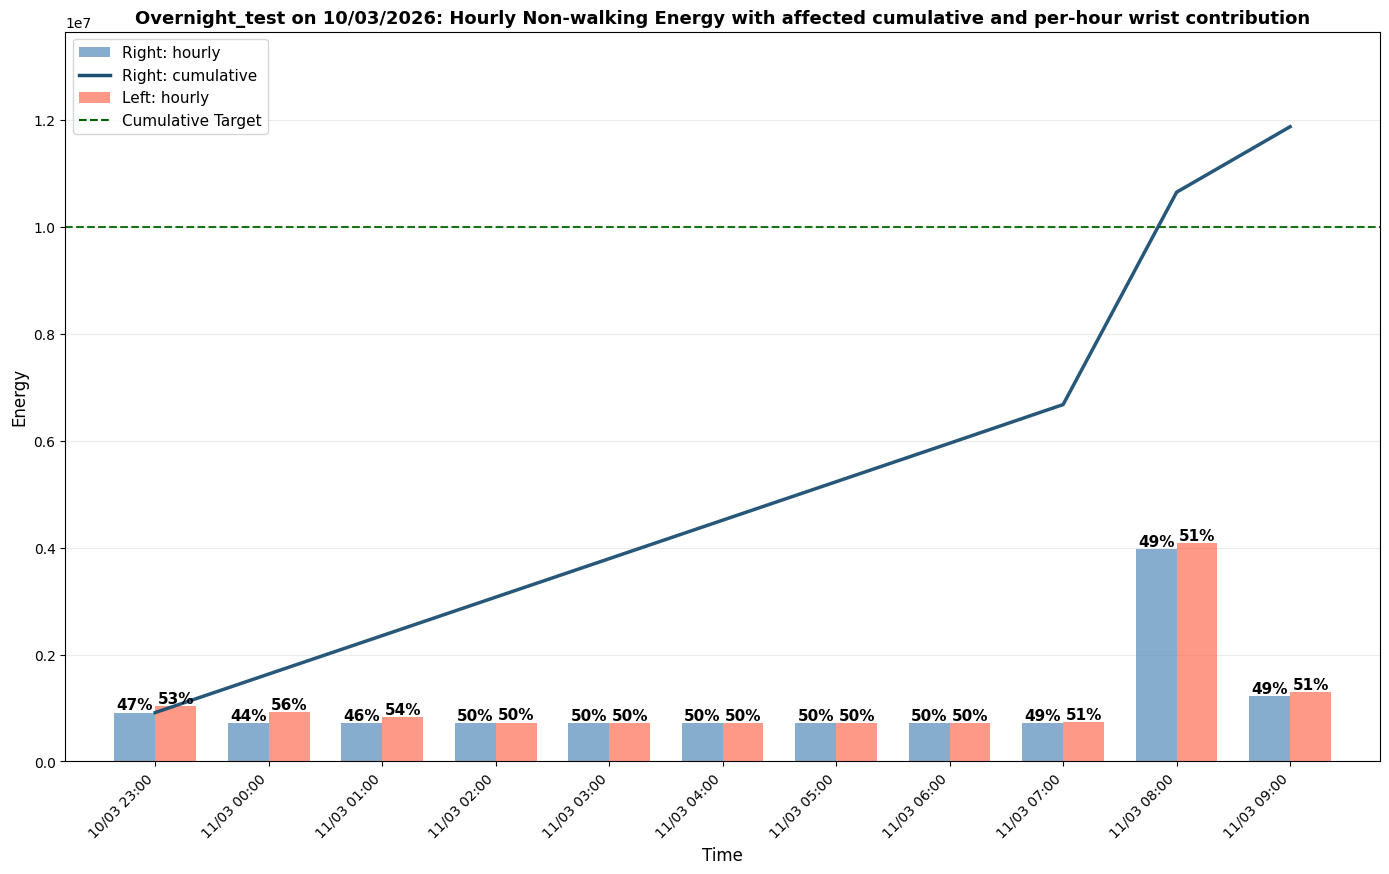

In [5]:
if not results:
    print("❌ No results found. Run Step 4 first.")
else:
    r = results[0] if results else None
    
    if r:
        %matplotlib inline
        plot_dir = os.path.join(RESULTS_DIR, 'Plots')
        os.makedirs(plot_dir, exist_ok=True)
    
        hf.plot_energy_results_bar([r], plot_dir, confirmed['wrist'], confirmed['target'])
        img_path = os.path.join(plot_dir, f"{r['subject']}_energy_bar.png")

        # Prepare Excel Link
        out_dir = os.path.join(RESULTS_DIR, 'Excel')
        hf.save_subject_excel(r, out_dir, confirmed['wrist'], confirmed['target'])
        xlsx_path = os.path.join(out_dir, f"{r['subject']}_energy.xlsx")
    else:
        print(f"❌ Result for '{confirmed['subject']}' not found.")